In [46]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-dataset/heart.csv


# Importing the necessary libraries

In [47]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the dataset and analyze the correlations

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


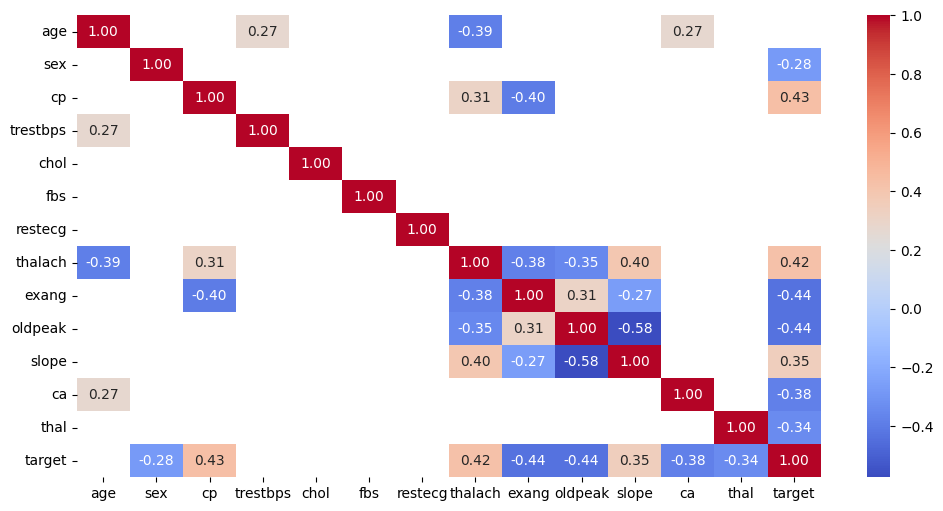

In [48]:
df=pd.read_csv("/kaggle/input/heart-disease-dataset/heart.csv")
print(df.head())
corr=df.corr()
plt.figure(figsize=(12,6))
mask=np.abs(corr)<=0.25
sns.heatmap(corr,mask=mask,cmap='coolwarm',annot=True,fmt='.2f')
plt.show()

# Correlations with the target:

**Positive:**
1. cp-0.43
2. thalach-0.42
3. slope-0.35

**Negative:**
1. exang=-0.44
2. oldpeak=-0.44
3. ca=-0.38
4. thal=-0.34
5. sex=-0.28

Model Training

In [49]:
x=df.drop(columns='target')
y=df['target']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report as cr,confusion_matrix as cm,accuracy_score as acc
log=LogisticRegression()
tree=DecisionTreeClassifier(max_depth=4,criterion='gini',random_state=42)
rf=RandomForestClassifier(n_estimators=100,max_depth=4,random_state=42)
models={"Logistic Regression":log,"Decision Tree":tree,"Random Forest":rf}
for model in models.values():
    model.fit(x_train,y_train)
    y_pred_train=model.predict(x_train)
    y_pred_test=model.predict(x_test)
    print("Train accuracy score:",acc(y_train,y_pred_train))
    print("Test accuracy score:",acc(y_test,y_pred_test))
    print("Confusion matrix:\n",cm(y_test,y_pred_test))
    print("Classification Report:\n",cr(y_test,y_pred_test))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train accuracy score: 0.8661087866108786
Test accuracy score: 0.8116883116883117
Confusion matrix:
 [[119  40]
 [ 18 131]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.75      0.80       159
           1       0.77      0.88      0.82       149

    accuracy                           0.81       308
   macro avg       0.82      0.81      0.81       308
weighted avg       0.82      0.81      0.81       308

Train accuracy score: 0.8967921896792189
Test accuracy score: 0.8344155844155844
Confusion matrix:
 [[121  38]
 [ 13 136]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.76      0.83       159
           1       0.78      0.91      0.84       149

    accuracy                           0.83       308
   macro avg       0.84      0.84      0.83       308
weighted avg       0.84      0.83      0.83       308

Train accuracy score: 0.9330543933054394
Test accura

# Decision Tree Visualization

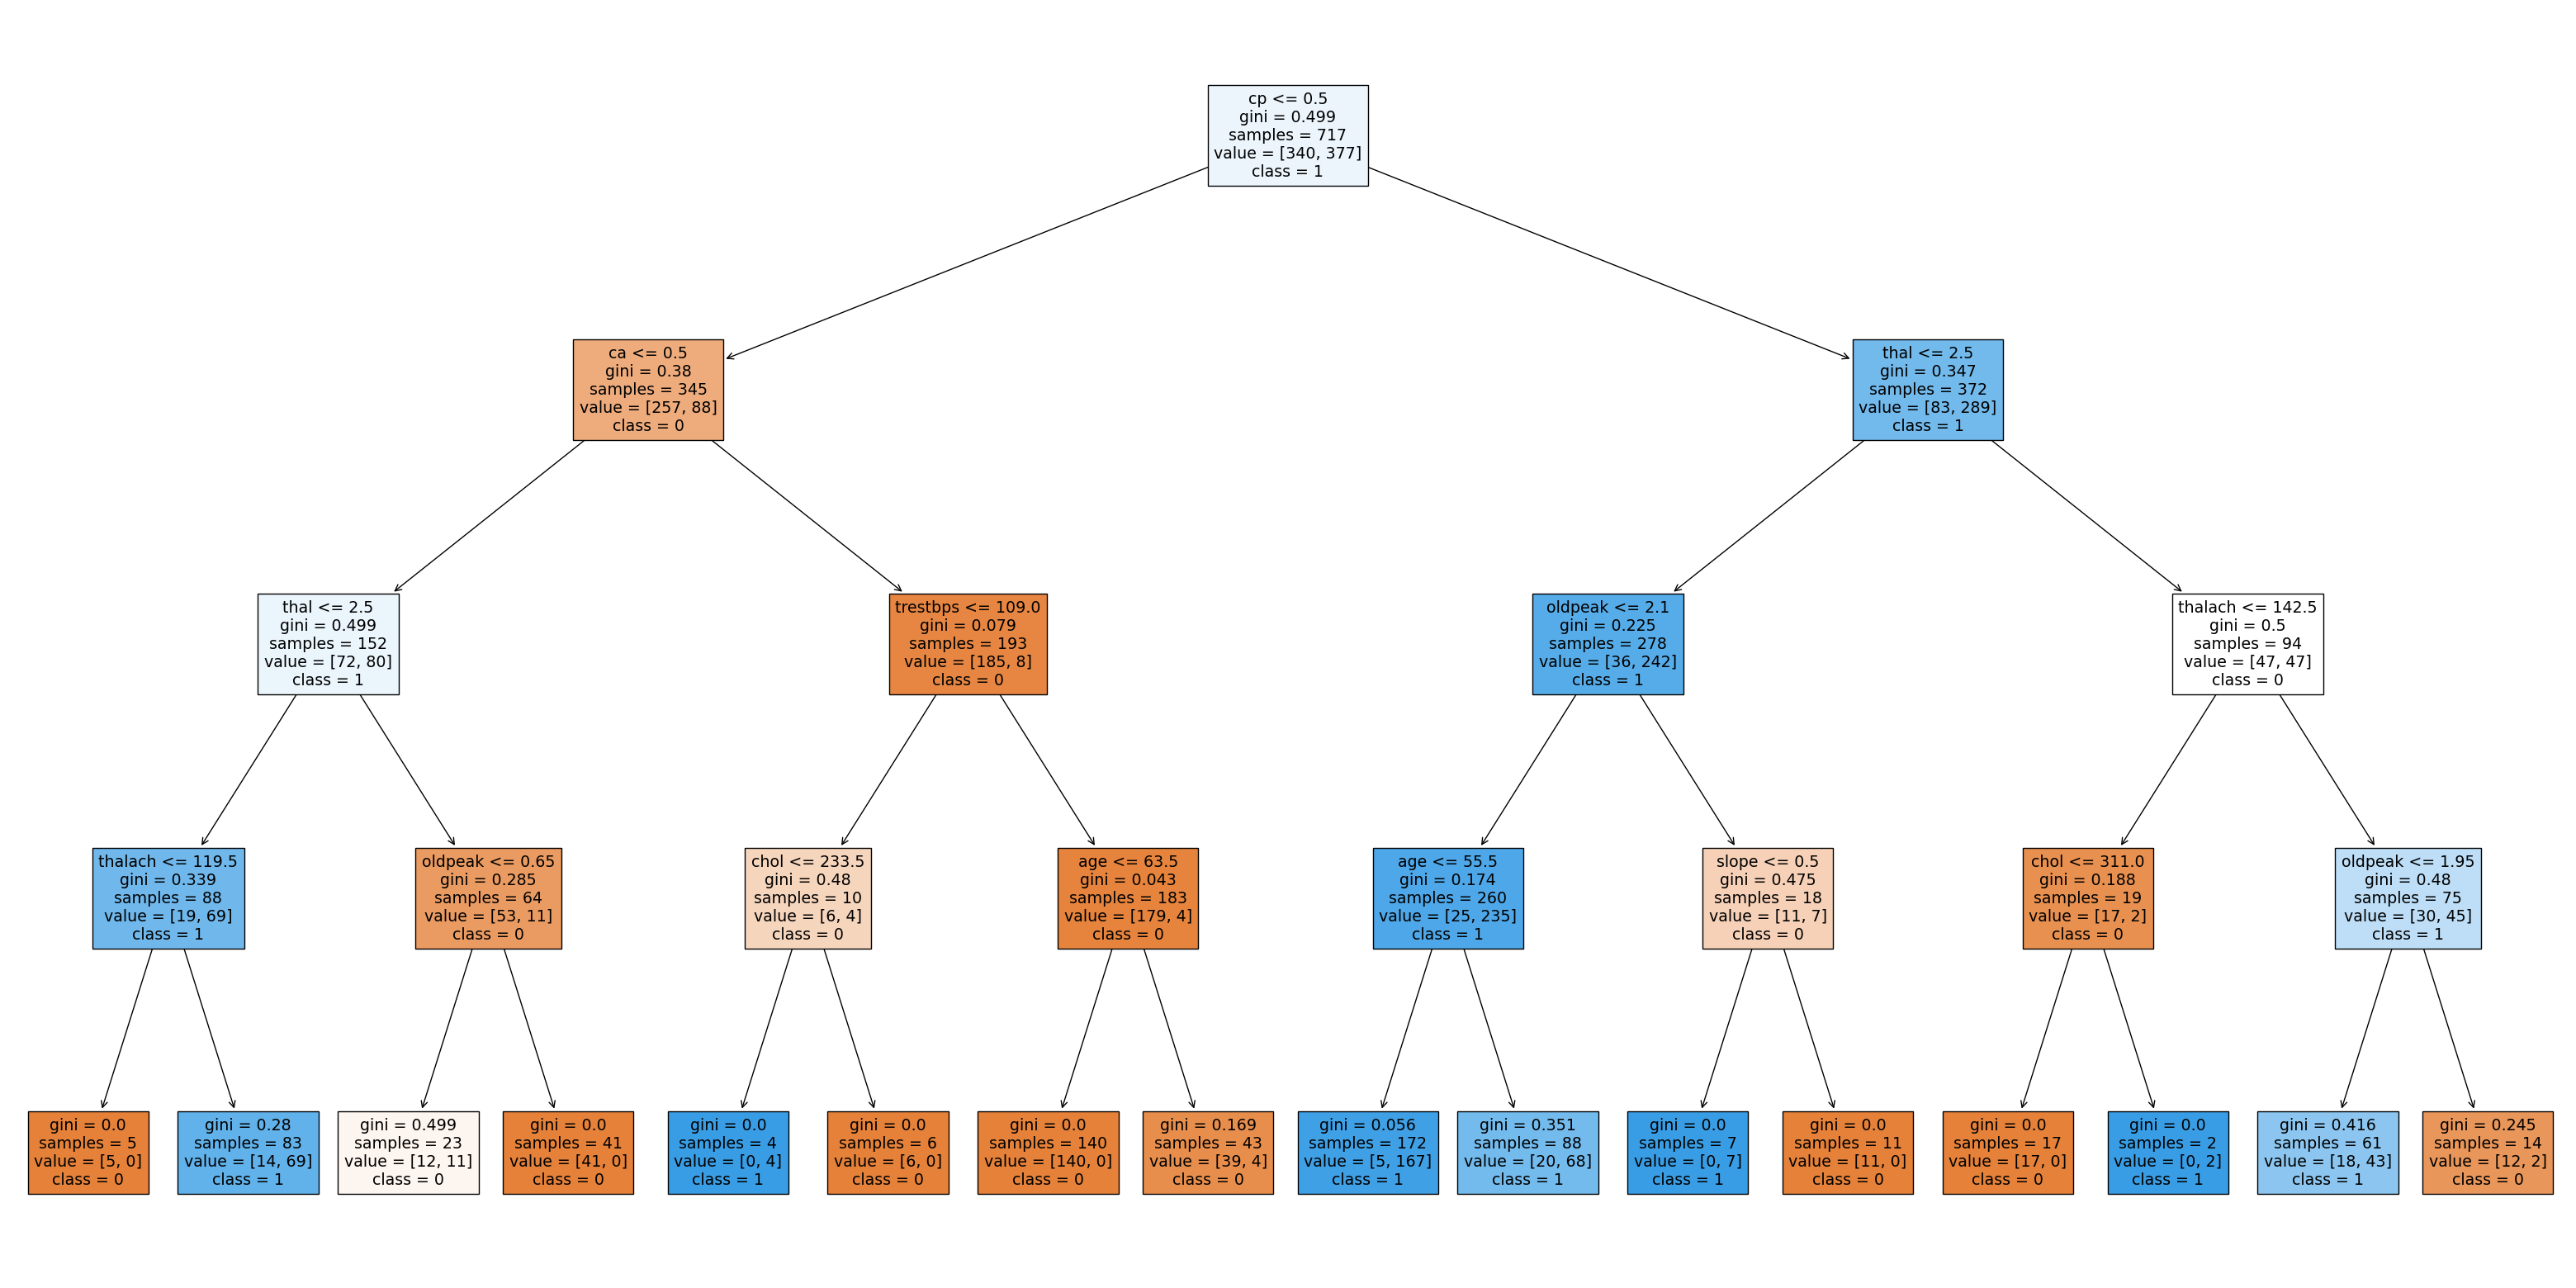

In [50]:
plt.figure(figsize=(40,20))
feature_names=x_train.columns.tolist()
plt.title("Tree Visualization")
plot_tree(tree,filled=True,feature_names=feature_names,class_names=['0','1'])
plt.show()

# Feature Importances

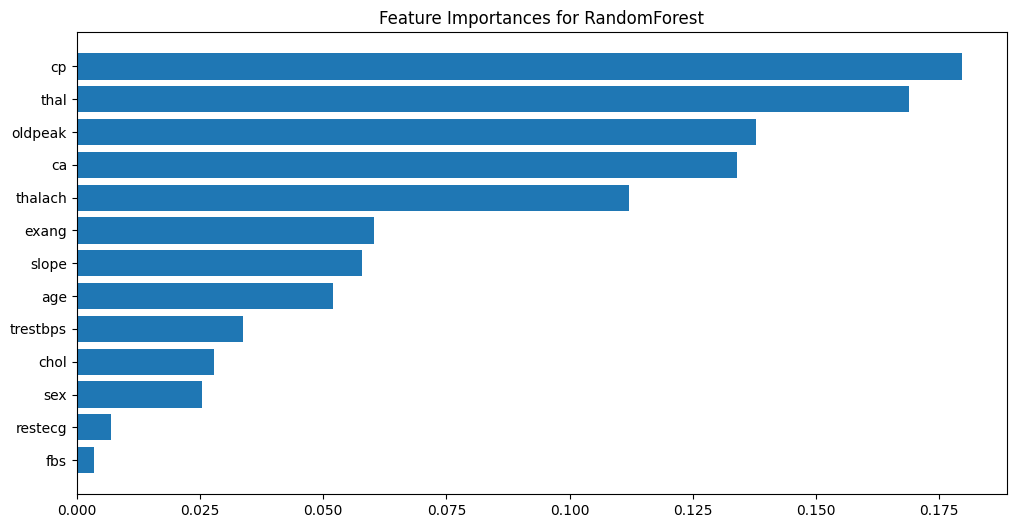

In [51]:
importances=rf.feature_importances_
indices=importances.argsort()
plt.figure(figsize=(12,6))
plt.barh(range(x.shape[1]),importances[indices],align='center')
plt.yticks(range(x.shape[1]),x.columns[indices])
plt.title("Feature Importances for RandomForest")
plt.show()

# Cross Validation

In [52]:
from sklearn.model_selection import cross_val_score,StratifiedKFold
skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
for name,model in models.items():
    print(name,"results:")
    acc=cross_val_score(model,x_train,y_train,cv=skf,scoring='accuracy')
    auc=cross_val_score(model,x_train,y_train,cv=skf,scoring='roc_auc')
    print(acc.mean())
    print(auc.mean())

Logistic Regression results:


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.8661087866108786
0.9245637890202398
Decision Tree results:
0.8340306834030683
0.915922810960538
Random Forest results:
0.8856345885634589
0.9530505713644978
